
# Lecture 3 Homework: Testing an Active ETF with the Fama–French 3‑Factor Model

**Objective:** Choose an *actively managed* ETF you’re interested in (e.g., `ARKK`, `ARKW`, `ARKG`, `QMOM`, etc.) and evaluate whether it delivers risk‑adjusted performance using the Fama–French 3‑Factor (FF3) model.

You will:
1. Pick a ticker and date range.
2. Download **monthly** prices and compute **excess returns**.
3. Download FF3 monthly factors.
4. Run the regression:

   \[ R_{it} - R_{ft} = \alpha + b_{MKT}\,MKT\!\_\mathrm{RF} + b_{SMB}\,SMB + b_{HML}\,HML + \epsilon_t \]
5. Interpret the coefficients and **explain the results**.
6. (Optional) Visualize residuals and fitted vs. actual.

> Deliverables: (a) A short written interpretation (5–10 sentences). (b) Regression table (betas, t‑stats, R², alpha in **bps/month** and **annualized**). (c) One figure of your choice.


In [1]:
import sys
print(sys.version)
try:
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import statsmodels.formula.api as smf
    print('✅ Libraries imported successfully')
except Exception as e:
    print('If imports fail, install with:')
    print('pip install yfinance pandas numpy matplotlib statsmodels pandas-datareader')
    raise


import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
✅ Libraries imported successfully


In [4]:
#SPMO (S&P 500 Momentum ETF) monthly prices
# Download monthly prices for SPMO from inception to 3/31/2026
spmo_data = yf.download('SPMO', start='2015-10-01', end='2026-04-01', interval='1mo')
spmo_prices = spmo_data['Close']

# Compute monthly returns
spmo_returns = spmo_prices.pct_change().dropna()

# Download FF3 factors (includes RF)
import pandas_datareader.data as web
ff3_factors = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='2015-10', end='2026-03')[0] / 100  # Monthly, in percent

# Align dates
common_dates = spmo_returns.index.intersection(ff3_factors.index)

# Display monthly prices
print("Monthly Prices for SPMO:")
print(spmo_prices)

[*********************100%***********************]  1 of 1 completed


Monthly Prices for SPMO:
Ticker            SPMO
Date                  
2015-10-01   23.148529
2015-11-01   23.387268
2015-12-01   22.812538
2016-01-01   21.978512
2016-02-01   21.934143
...                ...
2025-11-01  119.489510
2025-12-01  118.693703
2026-01-01  119.531822
2026-02-01  119.132950
2026-03-01  111.793716

[126 rows x 1 columns]


In [7]:
#SPMO monthly returns
print("Monthly Returns for SPMO:")
print(spmo_returns)

Monthly Returns for SPMO:
Ticker          SPMO
Date                
2015-11-01  0.010313
2015-12-01 -0.024574
2016-01-01 -0.036560
2016-02-01 -0.002019
2016-03-01  0.053803
...              ...
2025-11-01 -0.012983
2025-12-01 -0.006660
2026-01-01  0.007061
2026-02-01 -0.003337
2026-03-01 -0.061605

[125 rows x 1 columns]


In [13]:
# Load asset returns
ASSET = 'SPMO'  # or a single stock like 'AAPL'
asset_px = yf.download([ASSET], period='10y', interval='1d', auto_adjust=True)['Close'].dropna()
Ri = asset_px.pct_change().dropna()

# Use pandas-datareader to fetch FF factors (uncomment if available) ---
from pandas_datareader import data as pdr
ff = pdr.DataReader('F-F_Research_Data_Factors_Daily', 'famafrench')[0]
ff.index = pd.to_datetime(ff.index)
ff = ff / 100.0  # convert percent to decimal

# Join & compute excess returns
DF = Ri.join(ff[['Mkt-RF','SMB','HML','RF']], how='inner')
DF['Y'] = DF['SPMO'] - DF['RF']

# Rename the column to remove the hyphen
DF = DF.rename(columns={'Mkt-RF': 'MktRF'})

ff3 = smf.ols('Y ~ MktRF + SMB + HML', data=DF).fit()
print(ff3.summary())

[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     1662.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:20:16   Log-Likelihood:                 4656.8
No. Observations:                1218   AIC:                            -9306.
Df Residuals:                    1214   BIC:                            -9285.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0002      0.000      1.093      0.2

Interpretation: The P value of intercept shows 0.275. This means that there is a 27.50% chance that the data has errors or is significant enough to reject the idea that this ETF is risk-adjusted. If the P value were less than 0.1 or 10%, we'd likely be able to conclude the stock is risk-adjusted. The R-squared represents the distance between the linear model and the tested hypothesis. Because the R-squared returned is .804, this shows the data is generally pretty far from the line of best fit, which, along with the p value being much greater than 0.05 or 0.10, we can confirm that we must reject the hypothesis that the SPMO ETF is risk-adjusted.

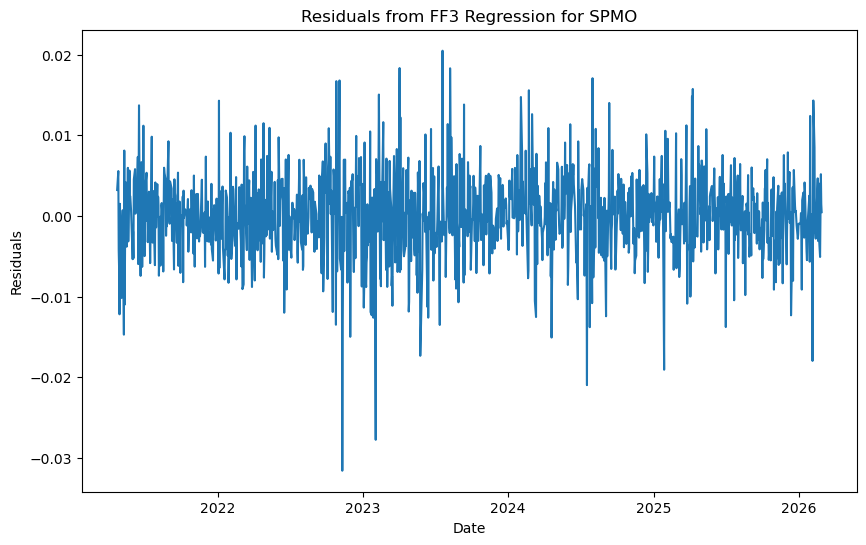

In [14]:
#Plotting residuals
plt.figure(figsize=(10,6))
plt.plot(DF.index, ff3.resid)
plt.title('Residuals from FF3 Regression for SPMO')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.show()